# IOCL RO Safety — COMBINED RISK ENGINE (LOCAL / VS Code)
Joins the two halves into the **Final Risk Index** your PWA displays.

`Final Risk Index = 0.40 × Numerical risk + 0.60 × Semantic risk`

- **Numerical risk** = 100 − compliance%  (from the numerical pipeline)
- **Semantic risk**  = (2·#High + 1·#Medium) / #items × 100  (matches your dataset's formula exactly)

The engine is pure functions — it takes risk labels as input, so the labels can come from the
**BERT bundle** (real path) or from the dataset (for bulk validation).

Setup: `pip install pandas numpy scikit-learn sentence-transformers matplotlib seaborn`

## STEP 0 — Imports & data

In [1]:
import pandas as pd, numpy as np, json, pickle, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt, seaborn as sns

items   = pd.read_csv('IOCL_Inspection_Dataset.csv')
summary = pd.read_csv('IOCL_Inspection_Summary.csv')
print('Items:', len(items), '| Inspections:', len(summary))

Items: 102528 | Inspections: 712


## STEP 1 — Numerical side (from the numerical pipeline)

In [2]:
def compliance(df):
    yes=(df['response']=='Yes').sum(); no=(df['response']=='No').sum()
    return round(100*yes/(yes+no),2) if (yes+no) else 0.0

def section_scores(df):
    out={}
    for sec,g in df.groupby('section'):
        y=(g['response']=='Yes').sum(); n=(g['response']=='No').sum()
        if y+n>0: out[sec]=round(100*y/(y+n),2)
    return out

def numerical_score(comp):
    return round(100-comp,2)   # 0 = safe, higher = riskier

## STEP 2 — Semantic side (matched to your dataset's formula)
High counts double; Medium counts single; Low counts zero — averaged over items, ×100.

In [3]:
def semantic_score(label_counts):
    H=label_counts.get('High',0); M=label_counts.get('Medium',0); L=label_counts.get('Low',0)
    total=H+M+L
    return round((2*H + 1*M)/total*100,2) if total else 0.0

## STEP 3 — The blend → Final Risk Index → risk band
Weights and thresholds are tunable policy choices (not learned). The High cutoff of 25
reproduces your dataset's own labels ~92%.

In [4]:
W_NUMERICAL, W_SEMANTIC = 0.40, 0.60
LOW_BELOW, HIGH_AT = 15, 25     # <15 Low | 15-25 Medium | >=25 High

def final_index(num, sem):
    return round(W_NUMERICAL*num + W_SEMANTIC*sem, 2)

def final_risk(idx):
    if idx >= HIGH_AT:   return 'High'
    if idx >= LOW_BELOW: return 'Medium'
    return 'Low'

def hidden_risks(df, labels=None):
    lab = pd.Series(labels, index=df.index) if labels is not None else df['risk_level']
    return int(((df['response']=='Yes') & (lab=='High')).sum())

## STEP 4 — The engine: one inspection in, full PWA payload out
`labels` = per-item risk predictions. If None, the dataset's own `risk_level` is used
(handy for bulk validation). In production you pass BERT's predictions here.

In [5]:
def assess(df, labels=None):
    comp = compliance(df)
    lab  = list(labels) if labels is not None else df['risk_level'].tolist()
    counts = pd.Series(lab).value_counts().to_dict()
    num = numerical_score(comp)
    sem = semantic_score(counts)
    idx = final_index(num, sem)
    secs = section_scores(df)
    return {
        'inspection_id': df['inspection_id'].iloc[0],
        'ro_name': df['ro_name'].iloc[0],
        'overall_risk': final_risk(idx),
        'final_risk_index': idx,
        'compliance_score': comp,
        'numerical_risk_score': num,
        'semantic_risk_score': sem,
        'hidden_risks': hidden_risks(df, labels),
        'section_flags': {s:v for s,v in sorted(secs.items(), key=lambda x:x[1]) if v < 70},
        'label_counts': counts,
    }

demo = assess(items[items['inspection_id']=='INSP00001'])
print(json.dumps(demo, indent=2))

{
  "inspection_id": "INSP00001",
  "ro_name": "IOCL RO Delhi Cantonment",
  "overall_risk": "High",
  "final_risk_index": 41.3,
  "compliance_score": 75.93,
  "numerical_risk_score": 24.07,
  "semantic_risk_score": 52.78,
  "hidden_risks": 1,
  "section_flags": {
    "Concreting": 0.0,
    "Abrasive_Blasting_Painting": 50.0,
    "Cutting_Welding_Grinding": 50.0,
    "Excavation": 50.0,
    "Safety_Awareness_Training": 50.0,
    "Welfare_Facilities": 66.67
  },
  "label_counts": {
    "Low": 93,
    "Medium": 26,
    "High": 25
  }
}


## STEP 5 — Bulk validation across all 712 inspections
Using the dataset's own labels, does the engine's final risk match the dataset's `overall_risk_level`?

In [6]:
rows=[]
for iid, df in items.groupby('inspection_id'):
    r = assess(df)
    rows.append({'inspection_id':iid, 'final_risk_index':r['final_risk_index'],
                 'engine_risk':r['overall_risk']})
res = pd.DataFrame(rows).merge(summary[['inspection_id','overall_risk_level']], on='inspection_id')
match = (res['engine_risk']==res['overall_risk_level']).mean()
print(f'Engine vs dataset label agreement: {match*100:.1f}%')
print('\nConfusion (rows=dataset, cols=engine):')
print(pd.crosstab(res['overall_risk_level'], res['engine_risk']))

Engine vs dataset label agreement: 90.9%

Confusion (rows=dataset, cols=engine):
engine_risk         High  Low  Medium
overall_risk_level                   
High                 468    0      54
Medium                 0   11     179


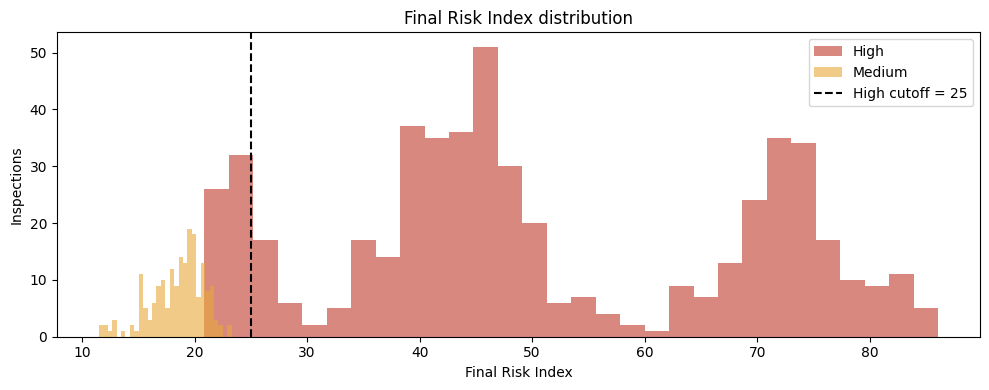

In [7]:
# Distribution of the Final Risk Index, coloured by dataset label
plt.figure(figsize=(10,4))
for lvl,c in [('High','#C0392B'),('Medium','#E8A838'),('Low','#5BA85B')]:
    d=res[res['overall_risk_level']==lvl]['final_risk_index']
    if len(d): plt.hist(d, bins=30, alpha=0.6, label=lvl, color=c)
plt.axvline(HIGH_AT, color='black', ls='--', label=f'High cutoff = {HIGH_AT}')
plt.xlabel('Final Risk Index'); plt.ylabel('Inspections'); plt.legend()
plt.title('Final Risk Index distribution'); plt.tight_layout(); plt.show()

## STEP 6 — REAL PATH: labels from your BERT bundle
This is what the PWA backend actually runs. Needs `risk_classifier_bundle.pkl` (from the semantic
notebook) in this folder; first call downloads the MiniLM encoder. Demo on one inspection's remarks.

In [9]:
with open('risk_classifier_bundle.pkl','rb') as f:
    bundle = pickle.load(f)
from sentence_transformers import SentenceTransformer
encoder = SentenceTransformer(bundle['encoder_name'])

def predict_labels(remarks):
    vecs = encoder.encode(list(remarks))
    idx  = bundle['classifier'].predict(vecs)
    return [bundle['labels'][i] for i in idx]

one = items[items['inspection_id']=='INSP00001'].copy()
bert_labels = predict_labels(one['remark'].astype(str))
result = assess(one, labels=bert_labels)
print('Using BERT-predicted labels (the production path):')
print(json.dumps(result, indent=2))

Using BERT-predicted labels (the production path):
{
  "inspection_id": "INSP00001",
  "ro_name": "IOCL RO Delhi Cantonment",
  "overall_risk": "High",
  "final_risk_index": 41.3,
  "compliance_score": 75.93,
  "numerical_risk_score": 24.07,
  "semantic_risk_score": 52.78,
  "hidden_risks": 3,
  "section_flags": {
    "Concreting": 0.0,
    "Abrasive_Blasting_Painting": 50.0,
    "Cutting_Welding_Grinding": 50.0,
    "Excavation": 50.0,
    "Safety_Awareness_Training": 50.0,
    "Welfare_Facilities": 66.67
  },
  "label_counts": {
    "Low": 93,
    "Medium": 26,
    "High": 25
  }
}


## STEP 7 — The PWA payload
`assess()` returns exactly what your front end renders: overall risk, the three scores,
hidden-risk count, and weak-section flags. This dict is what your backend API will return as JSON.

In [10]:
print('PWA receives this JSON per inspection:')
print(json.dumps(assess(items[items['inspection_id']=='INSP00007']), indent=2))

PWA receives this JSON per inspection:
{
  "inspection_id": "INSP00007",
  "ro_name": "IOCL RO Delhi Cantonment",
  "overall_risk": "High",
  "final_risk_index": 46.01,
  "compliance_score": 76.64,
  "numerical_risk_score": 23.36,
  "semantic_risk_score": 61.11,
  "hidden_risks": 1,
  "section_flags": {
    "Demolishing": 0.0,
    "Excavation": 0.0,
    "Hydrocarbon_Safety": 58.33,
    "Electrical_Safety": 62.5,
    "Welfare_Facilities": 66.67,
    "Working_at_Heights": 66.67
  },
  "label_counts": {
    "Low": 81,
    "Medium": 38,
    "High": 25
  }
}
